# 1. Classification

## Question 1

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report, mean_squared_error, r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from statistics import mean, stdev
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings("ignore")

In [20]:
data = pd.read_csv("data.csv", delimiter=";")
data.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [21]:
data['Target'] = data['Target'].replace({'Dropout': 0, 'Graduate': 1, 'Enrolled': 1})
data_all = data.copy()
data_target = data['Target']
data = data.drop('Target', axis=1)

## Question 2

In [22]:
# on normalise les valeurs de chaque attribut (tous sont de type numérique)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)


scaler = StandardScaler()
scaled_data_all = scaler.fit_transform(data_all)
scaled_data_all = pd.DataFrame(scaled_data_all, columns=data_all.columns)


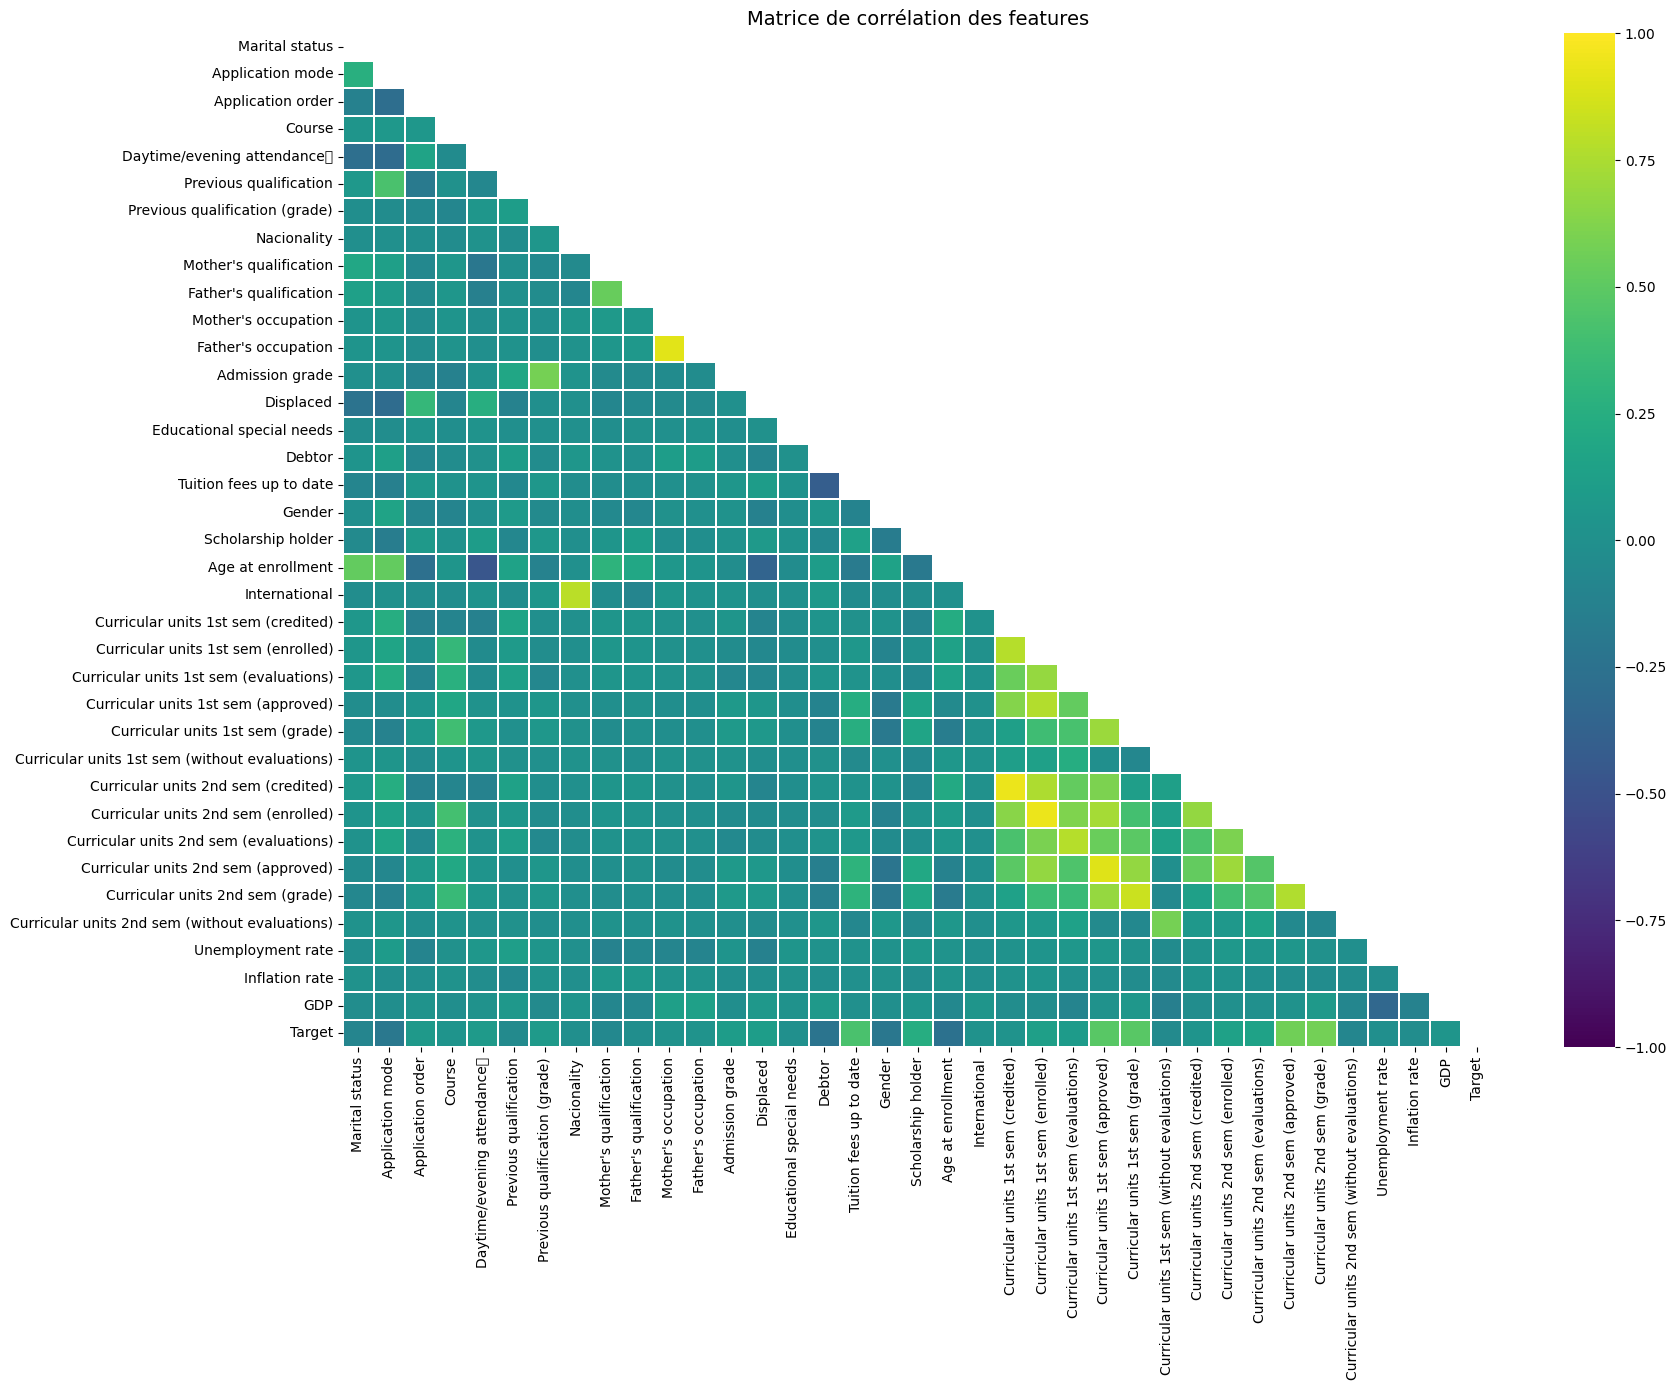

In [23]:
correlation_matrix = scaled_data_all.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='viridis', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot=False)
plt.title('Matrice de corrélation des features', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
threshold = 0.80
high_correlation_matrix = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] > threshold:
            high_correlation_matrix.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

if high_correlation_matrix:
    print(f"Features très semblables (r > {threshold} )")
    for a, b, r in sorted(high_correlation_matrix, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a} ~ {b}  r={r:.3f}')

Features très semblables (r > 0.8 )
  Curricular units 2nd sem (credited) ~ Curricular units 1st sem (credited)  r=0.945
  Curricular units 2nd sem (enrolled) ~ Curricular units 1st sem (enrolled)  r=0.943
  Father's occupation ~ Mother's occupation  r=0.910
  Curricular units 2nd sem (approved) ~ Curricular units 1st sem (approved)  r=0.904
  Curricular units 2nd sem (grade) ~ Curricular units 1st sem (grade)  r=0.837


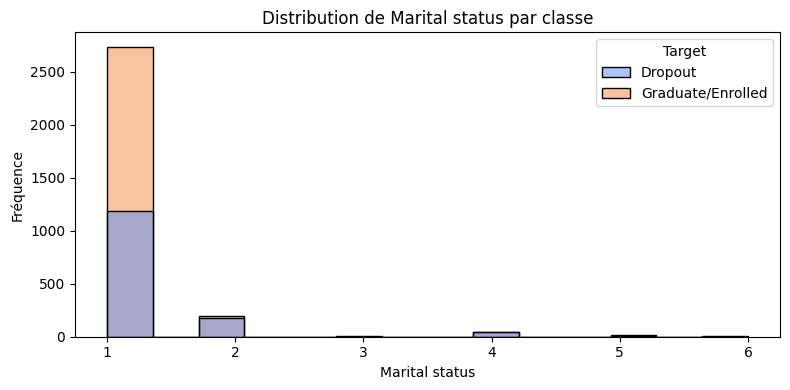

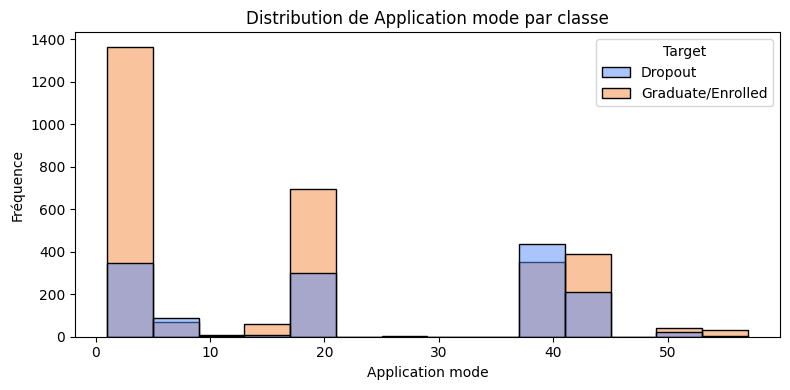

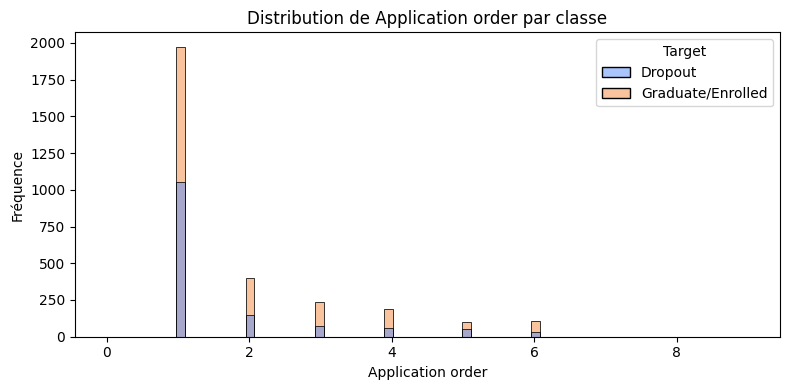

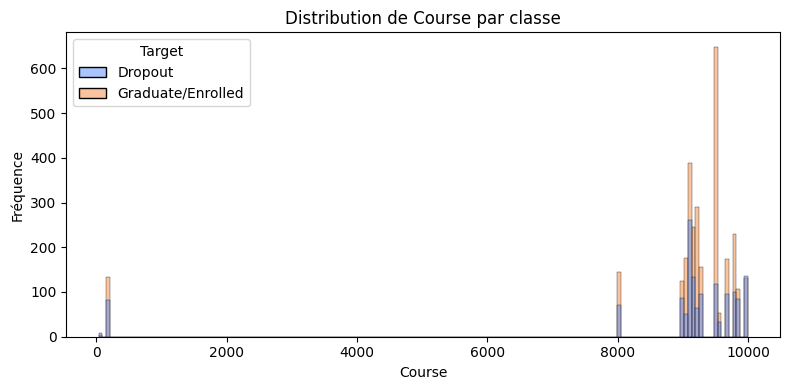

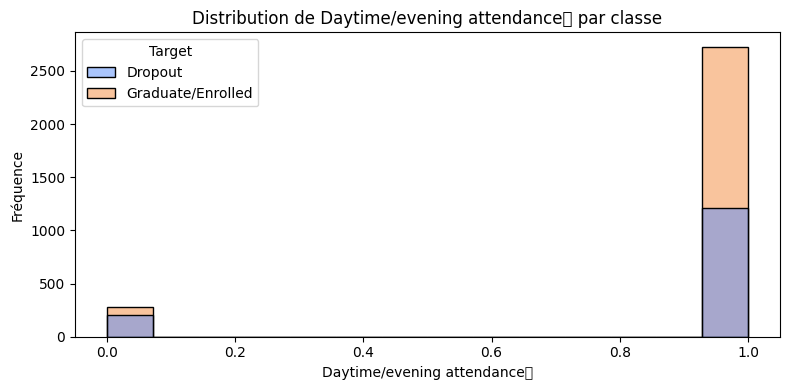

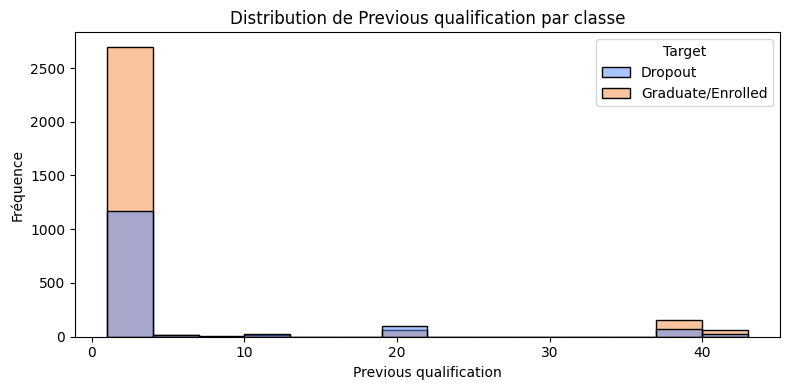

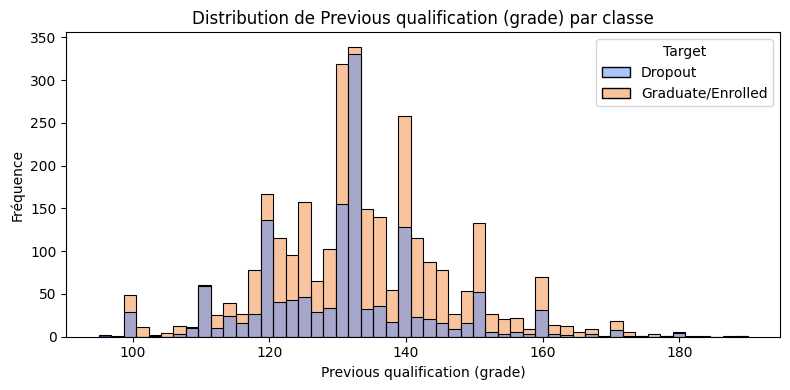

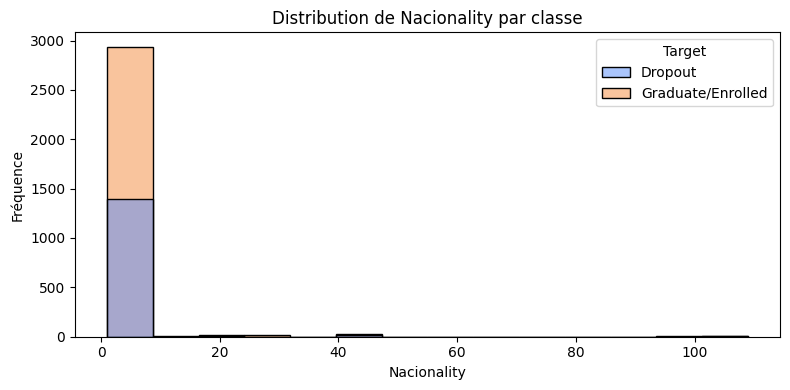

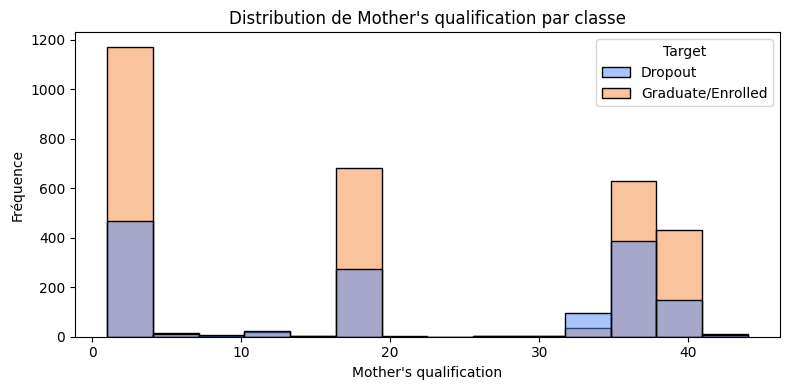

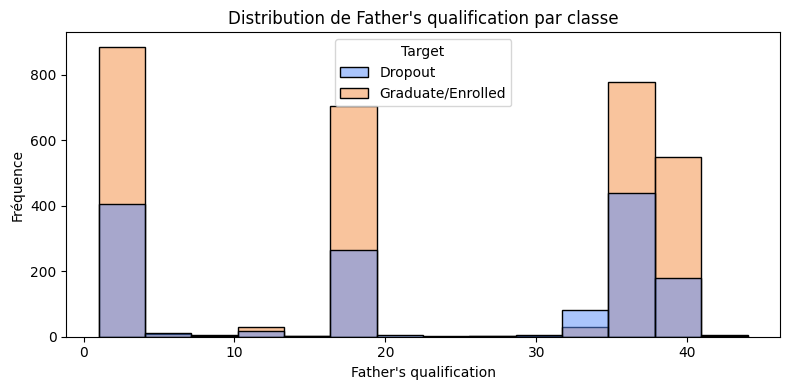

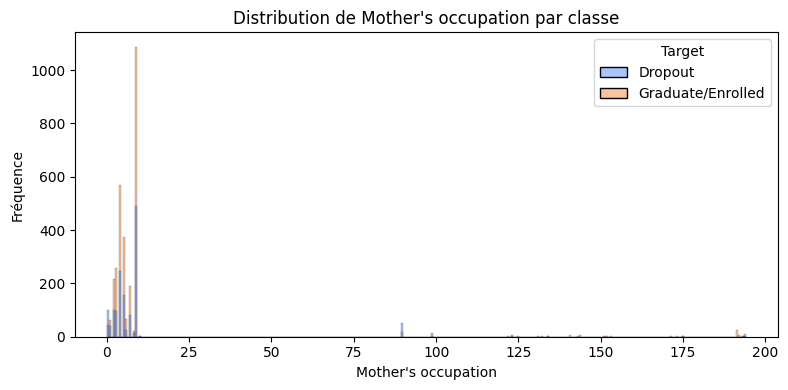

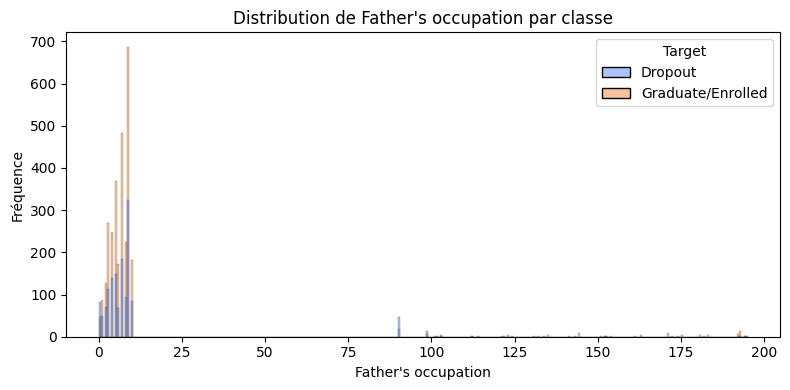

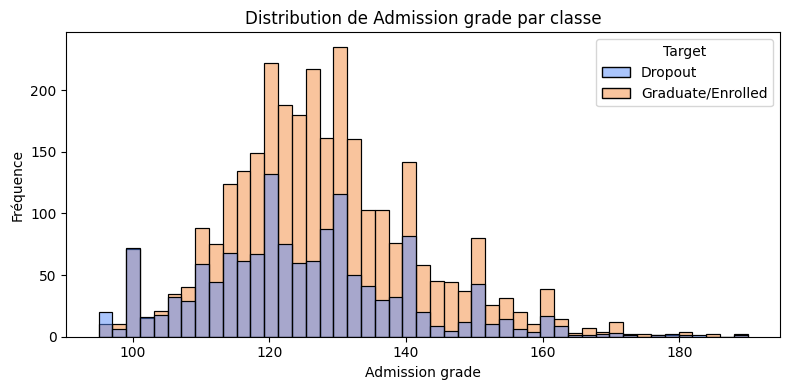

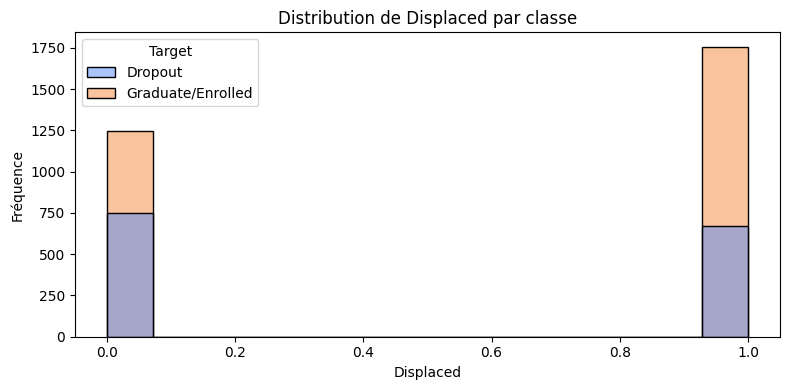

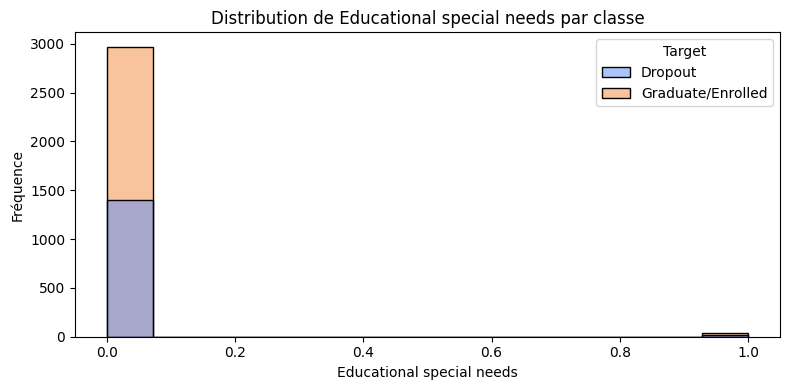

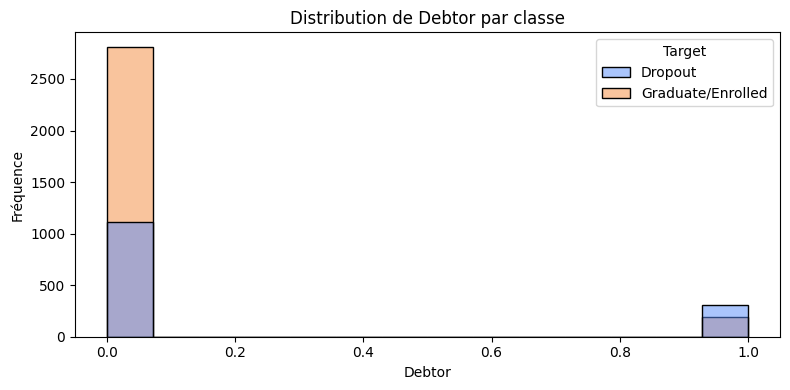

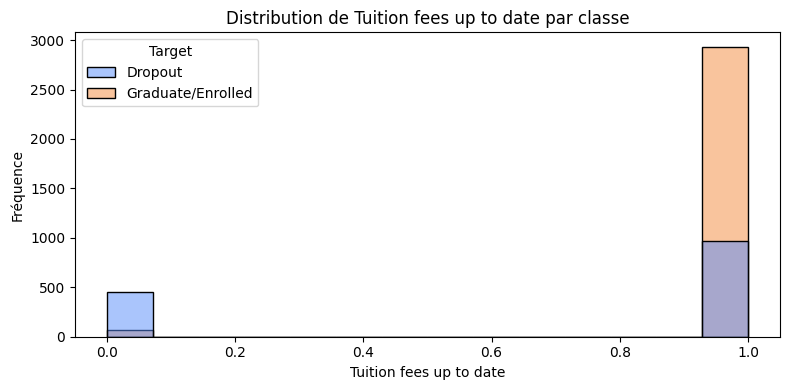

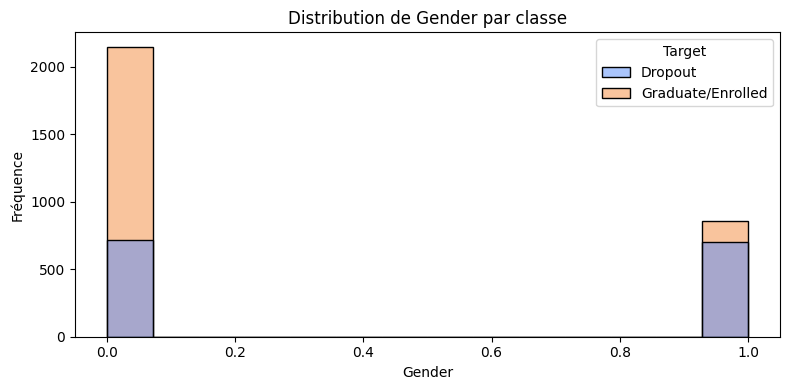

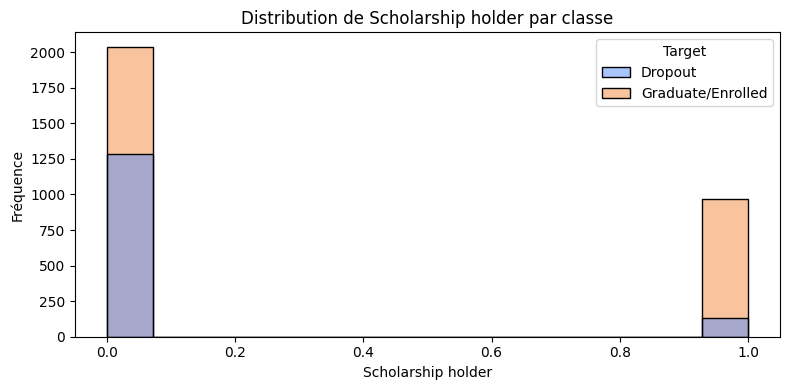

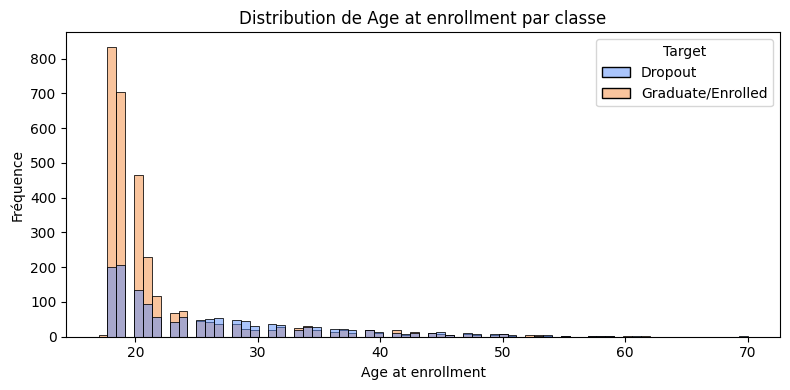

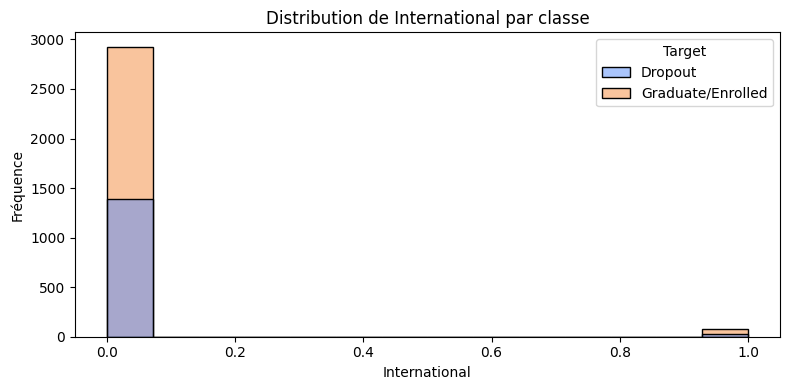

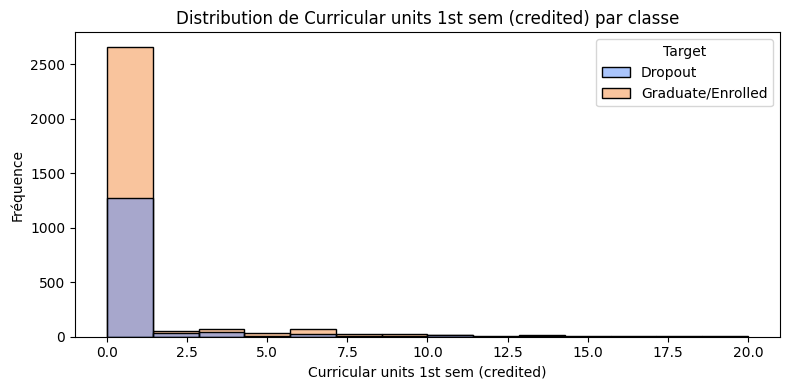

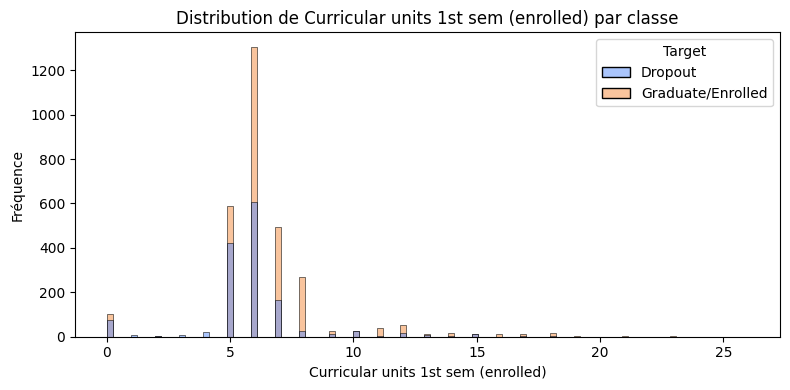

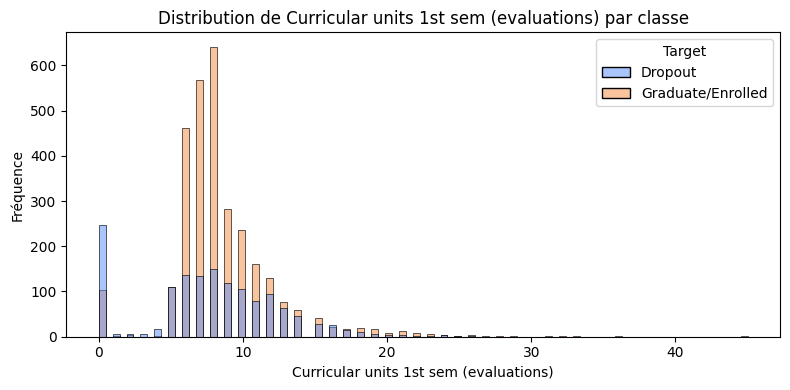

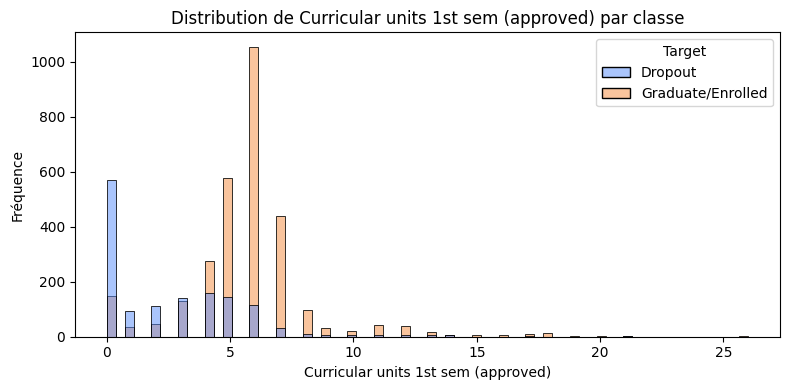

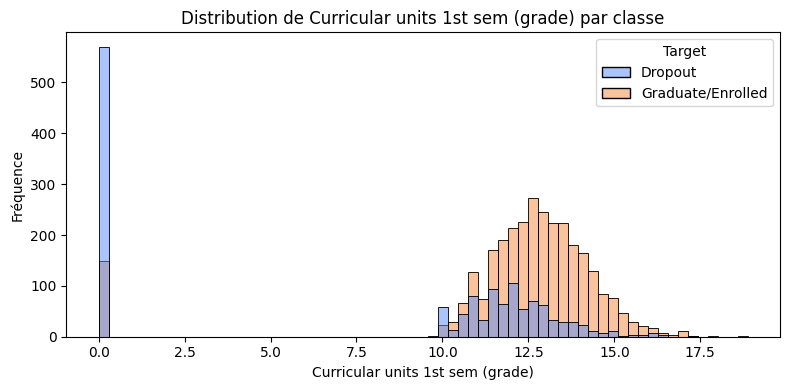

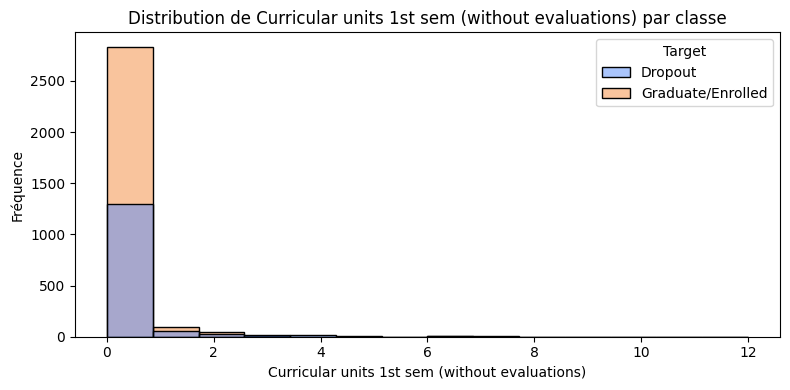

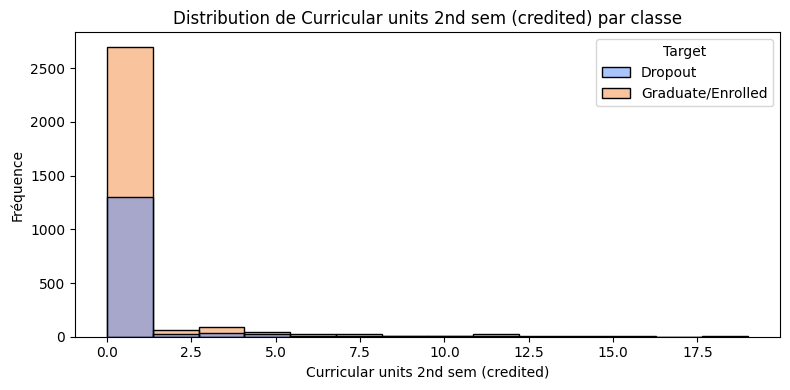

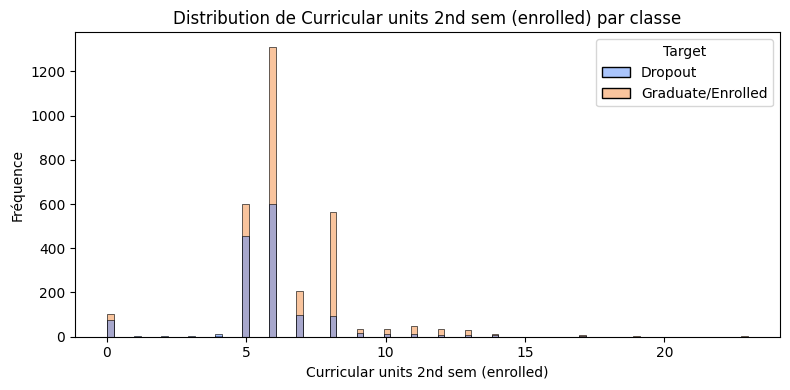

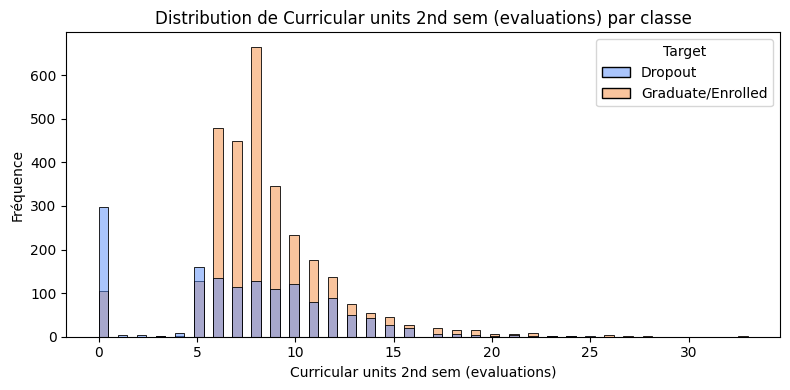

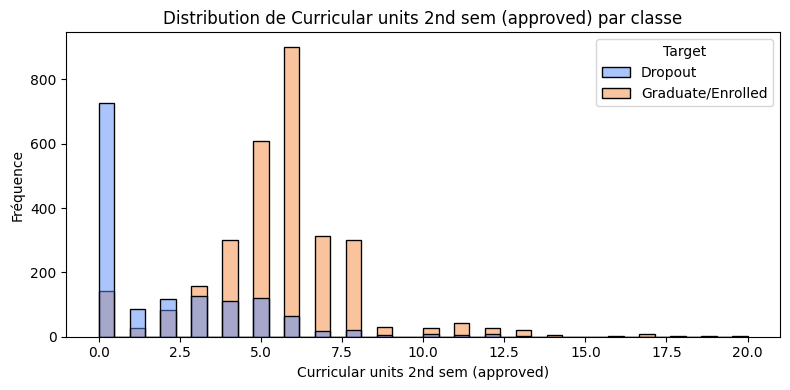

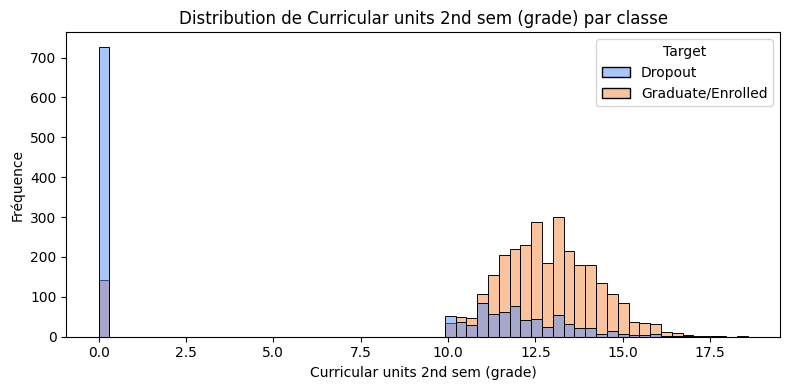

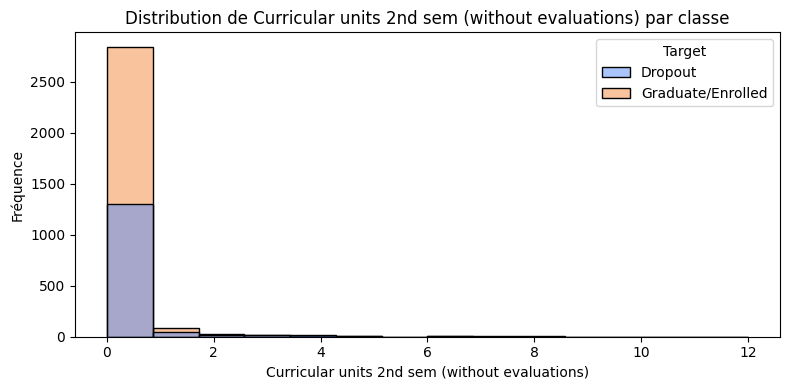

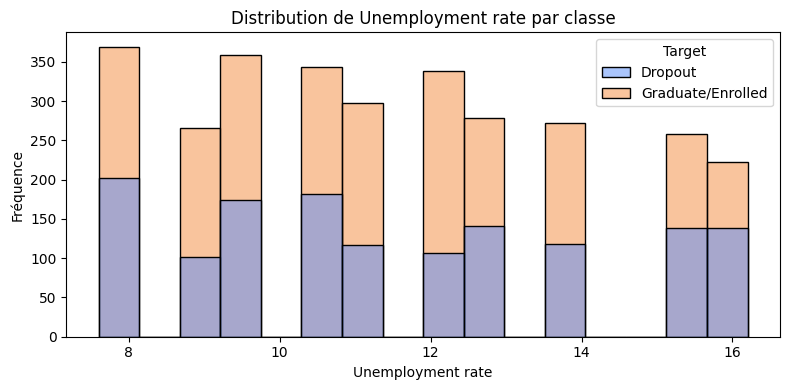

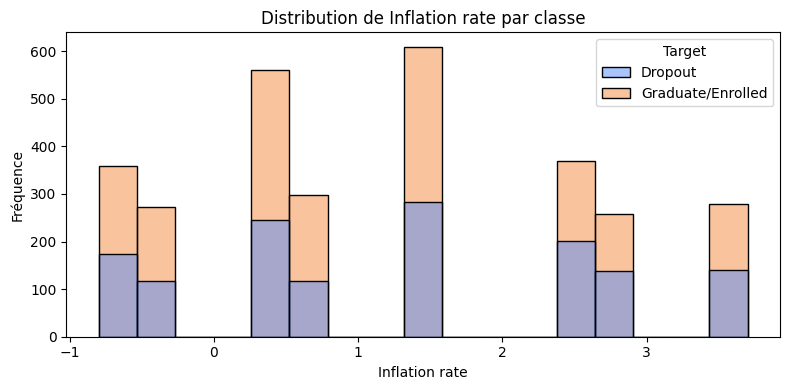

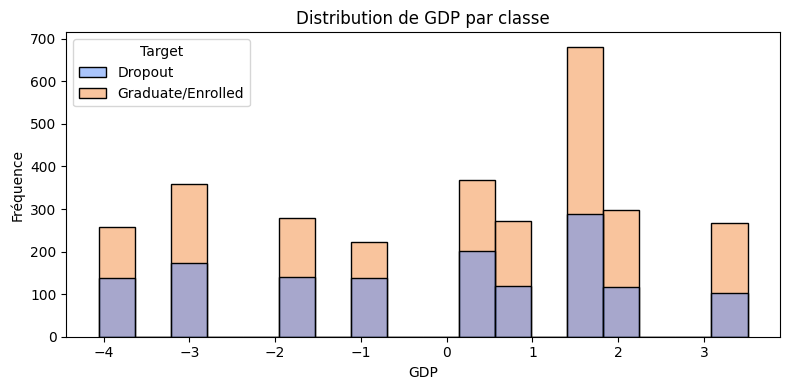

In [25]:
data_all_plot = data_all.copy()
data_all_plot["Target"] = data_all_plot["Target"].map({0: "Dropout", 1: "Graduate/Enrolled"})

for attribute in data.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=data_all_plot,
        x=attribute,
        hue="Target",
        hue_order=["Dropout", "Graduate/Enrolled"]  # ordre fixe de la légende
    )
    plt.title(f'Distribution de {attribute} par classe')
    plt.xlabel(attribute)
    plt.ylabel('Fréquence')
    plt.tight_layout()
    plt.show()



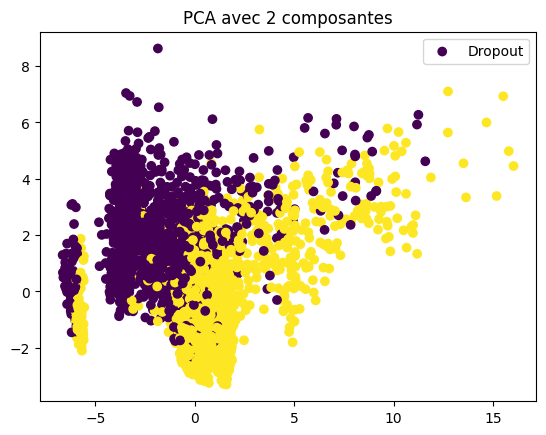

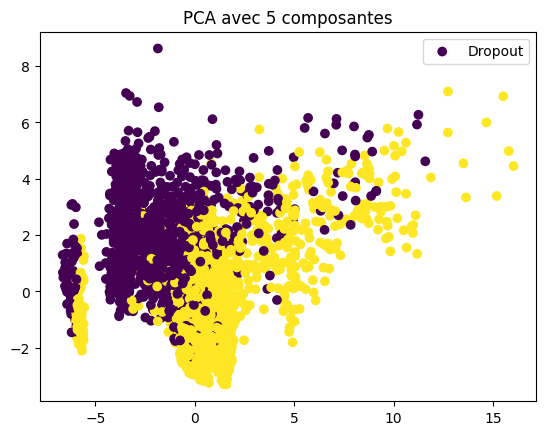

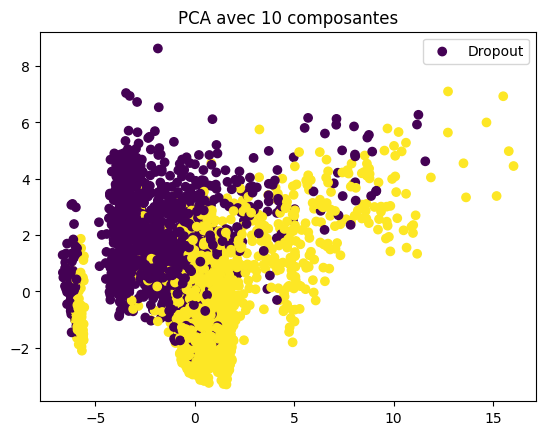

In [26]:
# PCA
import matplotlib.pyplot as plt
from sklearn import decomposition

for size in [2, 5, 10]:
    pca = decomposition.PCA(n_components=size)
    pca.fit(scaled_data_all)
    data2 = pca.transform(scaled_data_all)

    plt.scatter(data2[:,0], data2[:,1], c=data_target)
    plt.legend(['Dropout', 'Graduate/Enrolled'])
    plt.title(f'PCA avec {size} composantes')
    plt.show()

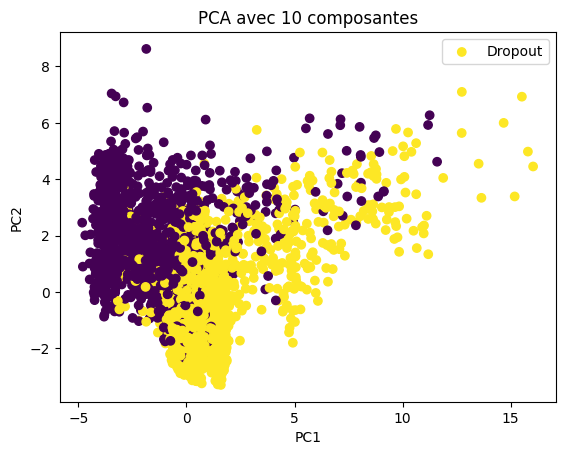

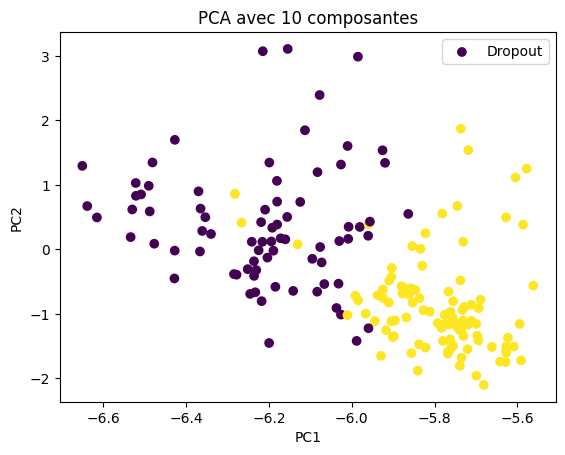

In [27]:
from pandas import DataFrame


pca = decomposition.PCA(n_components=2)
pca.fit(scaled_data_all)
data2 = pca.transform(scaled_data_all)
data2 = pd.DataFrame(data2, columns=[f'PC{i+1}' for i in range(2)])
data3main: DataFrame = data2.loc[data2['PC1'] > -5, :]
data3sub: DataFrame = data2.loc[data2['PC1'] <= -5, :]
target3main = data_target.loc[data3main.index]
target3sub = data_target.loc[data3sub.index]

plt.scatter(data3main['PC1'], data3main['PC2'], c=target3main)
plt.legend(['Dropout', 'Graduate/Enrolled'])
plt.title(f'PCA avec {size} composantes')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


plt.scatter(data3sub['PC1'], data3sub['PC2'], c=target3sub)
plt.legend(['Dropout', 'Graduate/Enrolled'])
plt.title(f'PCA avec {size} composantes')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Interprétation des résultats

##### Certains attributs ne semble pas être des facteurs déterminants puisqu'ils ont la même densité pour les dropout que les autres. Ces attributs sont principalement :
-GDP; Inflation Rate;

##### Certains attributs semblent être des facteurs déterminants
- Age (aux alentours de 20 réside toute la concentration de dropout)
- Scholarship (beaucoup plus de dropout chez ceux en possédant 1)
- Gender (plus de dropout chez 1 -> male)
- Displaced (plus de dropout chez 0 -> non displaced)
- Debtor (plus de dropout chez 1 -> debtor)
- Tuition fees (moins de dropout chez ceux qui payent des frais de scolarité)


## Question 3

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(scaled_data, data_target, test_size=0.1, random_state=42)

In [29]:
X_train

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
4244,-0.294829,-1.010660,-0.554068,-4.209520,0.350082,-0.35023,1.318488,-0.126298,-1.061566,-1.256427,...,-0.199273,1.802705,2.171449,0.997265,1.845857,0.479263,-0.199441,-1.000972,0.124386,1.545607
279,-0.294829,-1.010660,-0.554068,0.311805,0.350082,-0.35023,-0.274009,-0.126298,-0.036018,-0.213496,...,-0.199273,-0.282442,0.805144,0.743941,0.850642,0.687620,-0.199441,1.476924,1.137005,-1.789667
366,-0.294829,-1.010660,1.729655,0.311805,0.350082,-0.35023,0.256823,-0.126298,-0.036018,1.024985,...,-0.199273,-0.282442,0.349709,-0.269358,0.518904,0.729936,-0.199441,-1.489043,0.992345,0.140122
2536,-0.294829,1.391714,-0.554068,0.132483,0.350082,-0.35023,-2.473171,5.659289,-1.061566,-1.191244,...,2.695912,-0.282442,-0.561161,-0.269358,0.187165,0.942888,-0.199441,-0.813253,-1.466871,-1.375511
3708,-0.294829,-0.095470,1.729655,0.103404,0.350082,-0.35023,-0.349842,-0.126298,-1.189759,-1.386793,...,-0.199273,-0.282442,-0.105726,-0.016033,0.187165,0.301291,-0.199441,-0.175007,-0.454253,0.889126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,-0.294829,-1.010660,0.207173,0.103404,0.350082,-0.35023,0.105157,-0.126298,-1.189759,-0.213496,...,1.248320,-0.282442,-0.105726,0.743941,-0.144573,0.211724,-0.199441,0.876222,-1.105222,0.347199
466,-0.294829,-1.010660,-0.554068,0.482887,0.350082,-0.35023,0.029324,-0.126298,-1.189759,1.024985,...,-0.199273,1.802705,0.805144,-0.016033,1.182381,0.459634,-0.199441,1.476924,1.137005,-1.789667
3092,-0.294829,-1.010660,-0.554068,-0.408389,-2.856470,-0.35023,-2.473171,-0.126298,1.181819,-0.213496,...,-0.199273,-0.282442,-0.105726,-0.522682,0.518904,0.435643,-0.199441,0.425695,1.787974,-0.749872
3772,-0.294829,-1.010660,1.729655,0.184826,0.350082,-0.35023,-0.425675,-0.126298,-1.189759,1.024985,...,-0.199273,-0.282442,-0.105726,-0.269358,0.518904,0.613864,-0.199441,-0.175007,-0.454253,0.889126


In [30]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

rf = GradientBoostingClassifier()
rf.fit(X_train, y_train)
print(f"GradientBoostingClassifier initial accuracy: train {rf.score(X_train, y_train)} / test {rf.score(X_test, y_test)}")

Random Forest initial accuracy: train 0.9030394373273047 / test 0.8848758465011287


#### Interprétation

La différence entre le résultat sur les données de train et de test peut venir de plusieurs facteurs. Le premier est les outliers qui peuvent influer sur ces précisions. La seconde raison est l'agorithme choisi qui overfit plus ou moins. Celui que nous avons choisi, GradientBoostingClassifier limite cela en limitant la profondeur des arbres sur lesquels il regarde. Egalement il limite le nombre d'arbres sur lesquels il s'entraine. Par contre, l'algorithme RandomForestClassifier est entièrement déterministe (accuracy de 1 sur les données train), il construit l'arbresur les données qu'il a vu donc il s'en souvient.

## Question 4

In [31]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print(f"Random Forest initial accuracy (random_state): train {rf.score(X_train, y_train)} / test {rf.score(X_test, y_test)}")

Random Forest initial accuracy (random_state): train 1.0 / test 0.8848758465011287


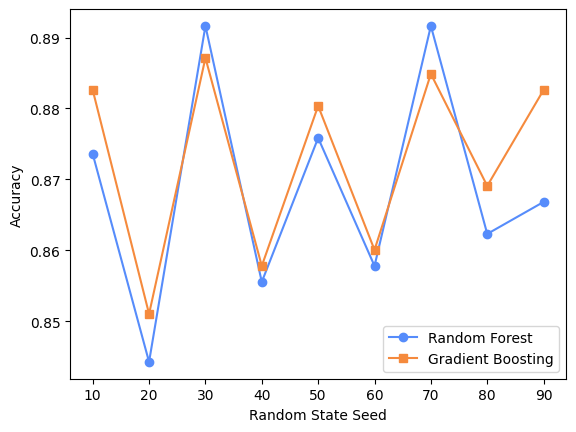

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

rf_accuracies = []
gb_accuracies = []
seed_range = [10, 20, 30, 40, 50, 60, 70, 80, 90]

for seed in seed_range:
    X_train, X_test, y_train, y_test = train_test_split(scaled_data, data_target, test_size=0.1, random_state=seed)
    # Random Forest
    rf_tmp = RandomForestClassifier()
    rf_tmp.fit(X_train, y_train)
    rf_accuracies.append(rf_tmp.score(X_test, y_test))

    # Gradient Boosting
    gb_tmp = GradientBoostingClassifier()
    gb_tmp.fit(X_train, y_train)
    gb_accuracies.append(gb_tmp.score(X_test, y_test))

import matplotlib.pyplot as plt

plt.plot(seed_range, rf_accuracies, label='Random Forest', marker='o')
plt.plot(seed_range, gb_accuracies, label='Gradient Boosting', marker='s')
plt.xlabel('Random State Seed')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Interprétation des résultats

Les résultats sont différents car nous avons environ 1/3 de target 0 et 2/3 de target 1.
Random splitting techniques like train_test_split() or regular K-Fold can create problem if they produce imbalanced class proportions in the training and test sets. For example imagine a binary classification dataset with 100 samples where:

    80 samples are Class 0
    20 samples are Class 1

Using random sampling in an 80:20 split then all 80 Class 0 in the training set and all 20 Class 1 in the test set. In this case model will never learn to classify Class 1 and would give misleading accuracy.


Donc en fonction de la seed choisie, les training/test sets peuvent tenir plus ou moins compte de la situation réelle.

## Question 5

In [33]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
cm = confusion_matrix(y_test, pred, normalize='true')
cm = cm
print(cm)

[[0.76923077 0.23076923]
 [0.06333333 0.93666667]]


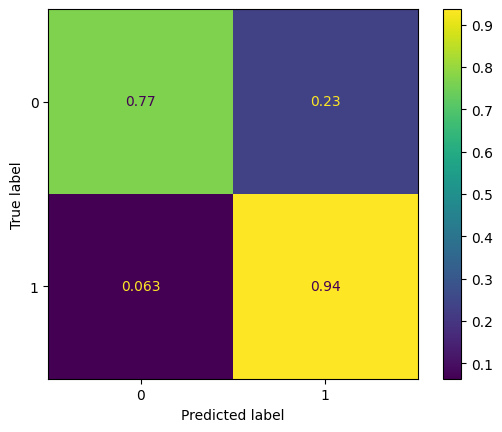

In [34]:

cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [35]:
# f1-score
f1_score(y_test, pred)

0.9153094462540716

#### Interprétation

| Terme | Définition                                   |
|-------|----------------------------------------------|
| **TP** | Étudiants Non-Dropout correctement prédits Non-Dropout |
| **TN** | Étudiants Dropout correctement prédits Dropout |
| **FP** | Étudiants Dropout mal prédits Non-Dropout    |
| **FN** | Étudiants Non-Dropout mal prédits Dropout    |

Avantage du F1-score sur l'accuracy:
L'accuracy peut être trompeuse sur des classes déséquilibrées (ex : si 80% sont Non-Dropout, un classifieur naïf qui prédit toujours 1 atteint 80% d'accuracy sans rien apprendre).
Le F1-score est la moyenne harmonique de la précision et du rappel, ce qui pénalise les faux positifs et les faux négatifs de façon équilibrée.

## Question 6

In [36]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=seed)

# Gradient Boosting
gb_tmp = GradientBoostingClassifier()
gb_tmp.fit(X_train, y_train)
print("Gradient Boosting Accuracy with 1% training data:", gb_tmp.score(X_test, y_test))

NameError: name 'X' is not defined

#### Interprétation

Avec si peu de données, le modèle n'a pas assez d'exemples pour apprendre les patterns. Il a un fort variance,  il sur apprend les quelques exemples vus et généralise mal.

On peut améliorer la qualité du classifier avec très peu de données.
Un Decision Tree avec profondeur limitée (`max_depth=4`) a moins de paramètres et donc biais plus fort mais une variance réduite et donc meilleure généralisation dans ce régime de données limitées.

C'est le biais-variance trade-off : quand les données sont rares, préférer des modèles plus simples qui sont moins propices à l'overfitting.

# 2. Regression

## Question 7

In [ ]:
measurements = pd.read_csv("measurements.csv", delimiter=',')

col_x, col_y = measurements.columns[0], measurements.columns[1]

X = measurements[[col_x]].values
y = measurements[col_y].values

lin_model = LinearRegression()
lin_model.fit(X, y)

y_pred_lin = lin_model.predict(X)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin  = r2_score(y, y_pred_lin)

print(f'Régression linéaire')
print(f'Coefficient : {lin_model.coef_[0]:.4f}')
print(f'Intercept : {lin_model.intercept_:.4f}')
print(f'MSE : {mse_lin:.4f}')
print(f'R²: {r2_lin}')

## Interprétation des résultats

##### MSE
- L'erreur absolue moyenne est relativement proche de 0 (0.49), ce qui veut dire qu'en moyenne les points sont proches de l'estimation linéaire faite.

#### R²
- Le coefficient de regression linéaire est proche de 1 (0.874), donc c'est un bon modèle

## Question 8

In [ ]:
degrees = [2, 8, 25]
colors  = ['seagreen', 'darkorange', 'purple']

results = []
x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, len(degrees), figsize=(16, 5), sharey=False)

for ax, deg, color in zip(axes, degrees, colors):
    poly_model = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False),
        LinearRegression()
    )
    poly_model.fit(X, y)

    y_pred = poly_model.predict(X)
    mse    = mean_squared_error(y, y_pred)
    r2     = r2_score(y, y_pred)
    results.append({'Degré': deg, 'MSE': mse, 'R²': r2})

    y_curve = poly_model.predict(x_plot)

    ax.scatter(X, y, color='steelblue', alpha=0.6, edgecolors='white', s=25, linewidths=0.3)
    ax.plot(x_plot, y_curve, color=color, linewidth=2)
    ax.set_title(f'Degré {deg}\nMSE={mse:.2f}  R²={r2:.4f}', fontsize=11)
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)

plt.suptitle('Régression polynomiale - comparaison des degrés', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

df_results = pd.DataFrame([{'Degré': 1, 'MSE': mse_lin, 'R²': r2_lin}] + results)
print(df_results.to_string(index=False))

In [ ]:
all_degrees = [1, 2, 8, 25]
mse_vals = df_results['MSE'].values
r2_vals  = df_results['R²'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(all_degrees, mse_vals, marker='o', color='tomato')
ax1.set_xlabel('Degré du polynôme')
ax1.set_ylabel('MSE (sur le train)')
ax1.set_title('MSE en fonction du degré')
ax1.set_xticks(all_degrees)

ax2.plot(all_degrees, r2_vals, marker='o', color='steelblue')
ax2.set_xlabel('Degré du polynôme')
ax2.set_ylabel('R² (sur le train)')
ax2.set_title('R² en fonction du degré')
ax2.set_xticks(all_degrees)

plt.tight_layout()
plt.show()